# Tutorial: Agglomerative Clustering

Este notebook presenta una implementación breve de **clustering jerárquico aglomerativo**, basada en la idea general del artículo de Soner Yildirim *Hierarchical Clustering — Explained*. Se agregan comentarios esenciales para entender el flujo: datos → estandarización → dendrograma → `AgglomerativeClustering` → evaluación.

Referencia: https://towardsdatascience.com/hierarchical-clustering-explained-e58d2f936323

## 1. Librerías
Usaremos `scikit-learn` para el modelo y `scipy` para construir el dendrograma.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


## 2. Datos de ejemplo
Trabajaremos con dos características para que el proceso pueda visualizarse fácilmente. En un problema real, estas columnas representarían variables medidas para cada observación.

In [2]:
X = np.array([[1.0,1.2],[1.3,1.0],[0.8,1.5],[1.2,1.7],
              [5.0,5.2],[5.4,4.8],[4.7,5.5],[5.2,5.7],
              [8.5,1.0],[8.8,1.4],[9.2,0.8],[9.0,1.7]])

df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])
df

,Feature_1,Feature_2
0,1.0,1.2
1,1.3,1.0
2,0.8,1.5
3,1.2,1.7
4,5.0,5.2
5,5.4,4.8
6,4.7,5.5
7,5.2,5.7
8,8.5,1.0
9,8.8,1.4


## 3. Visualización inicial
Antes de aplicar clustering, observamos la distribución de las muestras.

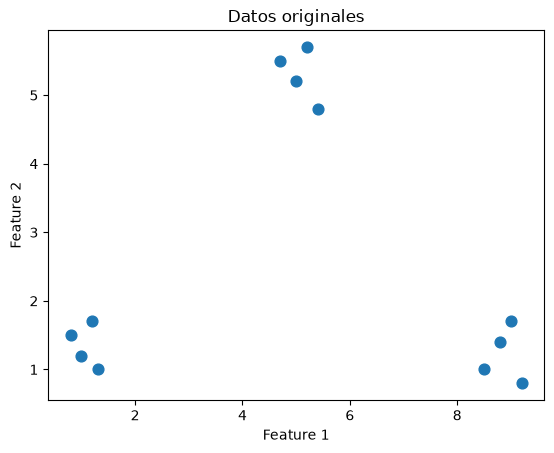

In [3]:
plt.scatter(df["Feature_1"], df["Feature_2"], s=60)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Datos originales")
plt.show()

## 4. Estandarización
El clustering depende de distancias. Si las variables están en escalas muy diferentes, una de ellas puede dominar el resultado; por eso es habitual estandarizarlas.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.25511339, -0.7424754 ],
       [-1.16117559, -0.84668248],
       [-1.3177386 , -0.58616479],
       [-1.19248819, -0.48195772],
       [-0.00260938,  1.34166608]])

## 5. Dendrograma
El dendrograma muestra la jerarquía de fusiones. Usamos `ward`, que busca fusiones que minimicen el incremento de la variabilidad interna.

**Lectura:** cuanto mayor es la altura de una fusión, mayor es la distancia entre los grupos que se están uniendo. Un corte horizontal permite definir el número de clústeres.

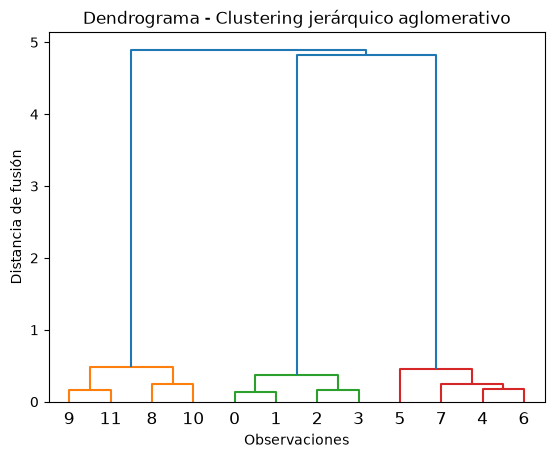

In [5]:
Z = linkage(X_scaled, method="ward")
dendrogram(Z)
plt.title("Dendrograma - Clustering jerárquico aglomerativo")
plt.xlabel("Observaciones")
plt.ylabel("Distancia de fusión")
plt.show()

## 6. Agglomerative Clustering
Ahora implementamos el algoritmo directamente con `scikit-learn`. El dendrograma sugiere una separación natural en **3 grupos**, por lo que usamos `n_clusters=3`.

In [6]:
model = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = model.fit_predict(X_scaled)
df["Cluster"] = labels
df

,Feature_1,Feature_2,Cluster
0,1.0,1.2,2
1,1.3,1.0,2
2,0.8,1.5,2
3,1.2,1.7,2
4,5.0,5.2,1
5,5.4,4.8,1
6,4.7,5.5,1
7,5.2,5.7,1
8,8.5,1.0,0
9,8.8,1.4,0


## 7. Visualización de los grupos

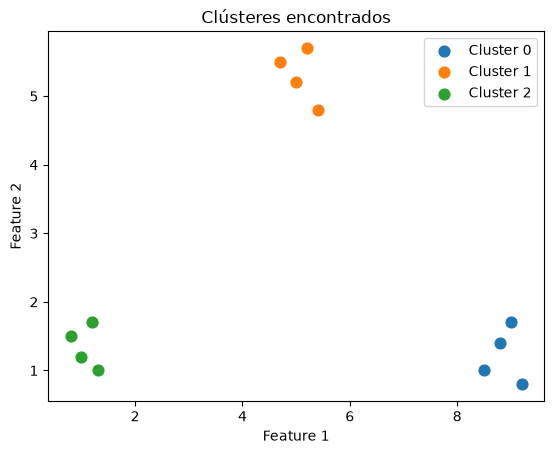

In [7]:
for cluster in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(subset["Feature_1"], subset["Feature_2"], s=60, label=f"Cluster {cluster}")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clústeres encontrados")
plt.legend()
plt.show()

## 8. Evaluación con Silhouette Score
Como no tenemos etiquetas reales, no podemos usar métricas supervisadas como accuracy. El **Silhouette Score** permite evaluar, de forma no supervisada, qué tan bien separados están los grupos. Valores cercanos a 1 indican mayor cohesión y separación.

In [8]:
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.882


Tarea: Profundice un poco mas en el silhouette score, investigue cual es la formula que lo define y como se calcula, que quieren decir los terminos: Cohesión (a) y Separación (b)

## 9. Probar diferentes números de clústeres
Una ventaja del enfoque jerárquico es que la jerarquía construida puede explorarse con diferentes cortes. Aquí comparamos varios valores de `n_clusters` mediante Silhouette Score.

In [9]:
results = []
for k in range(2, 6):
    model_k = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_k = model_k.fit_predict(X_scaled)
    results.append([k, silhouette_score(X_scaled, labels_k)])

pd.DataFrame(results, columns=["n_clusters","silhouette_score"])

,n_clusters,silhouette_score
0,2,0.549998
1,3,0.881714
2,4,0.726415
3,5,0.531643


## 10. Lo esencial
- **Es un método no supervisado.**
- Cada observación comienza como un clúster individual.
- En cada iteración se fusionan los clústeres más cercanos según el criterio de `linkage`.
- El **dendrograma** muestra toda la jerarquía de fusiones.
- `n_clusters` define cuántos grupos finales queremos.
- La escala de las variables y el método de `linkage` pueden cambiar el resultado.
- El **Silhouette Score** ayuda a evaluar la separación cuando no existen etiquetas conocidas.

## Aplicación práctica
En un entorno empresarial, este procedimiento puede utilizarse para **segmentar clientes** a partir de variables como frecuencia de compra, gasto promedio y número de productos adquiridos. En ingeniería también puede servir para agrupar sensores, equipos o procesos según sus características de operación cuando no existen etiquetas previas.